#ANALOG TO DIGITAL CONVERSION

In [24]:
import numpy as np;
import matplotlib.pyplot as plt;
from matplotlib import style;

In [25]:
t=np.arange(0,20,1)
print(t)
x=(.85)**t
x

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


array([1.        , 0.85      , 0.7225    , 0.614125  , 0.52200625,
       0.44370531, 0.37714952, 0.32057709, 0.27249053, 0.23161695,
       0.1968744 , 0.16734324, 0.14224176, 0.12090549, 0.10276967,
       0.08735422, 0.07425109, 0.06311342, 0.05364641, 0.04559945])

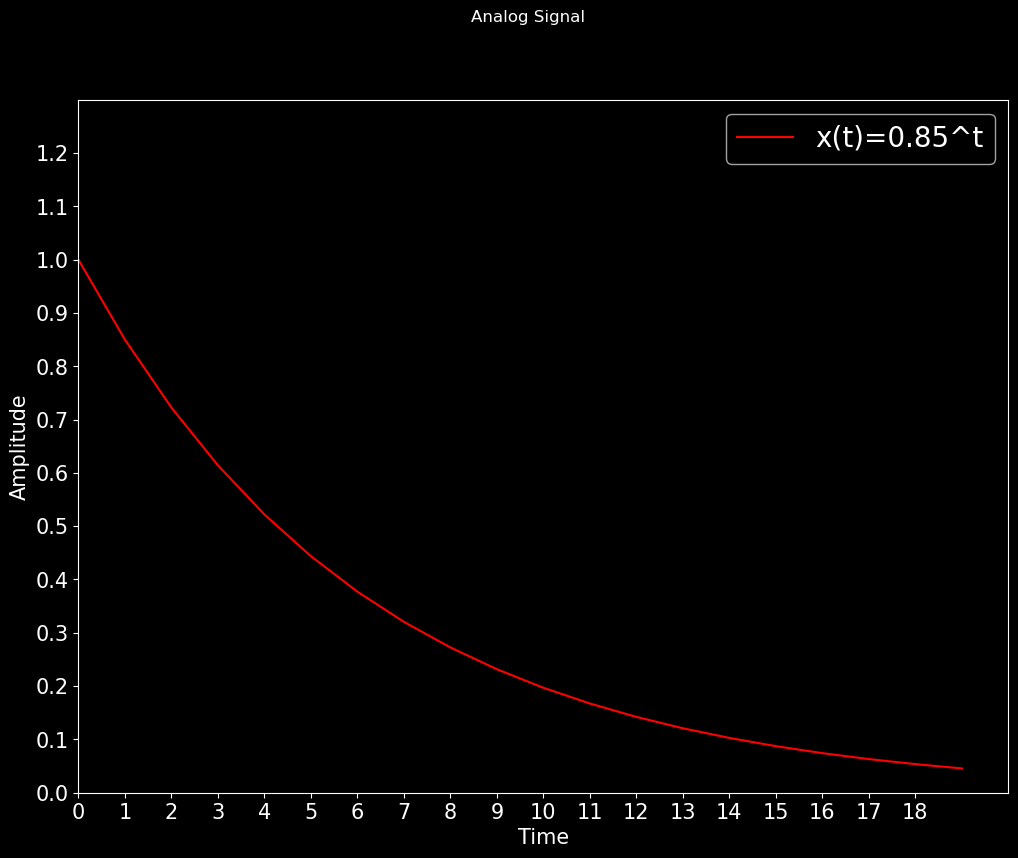

In [26]:
#Plotting Analog Signal
plt.figure(figsize=(12,9))
plt.suptitle("Analog Signal")
style.use('dark_background')
plt.rcParams['xtick.labelsize']=15 #
plt.rcParams['ytick.labelsize']=15

plt.plot(t,x,'r',label='x(t)=0.85^t')
plt.xlabel("Time",fontsize=15)
plt.ylabel("Amplitude",fontsize=15)
plt.axis([0,20,0,1.3]) #
plt.legend(fontsize=20)

xt=np.arange(0,19,1)
yt=np.arange(0,1.3,0.1)

plt.xticks(xt)
plt.yticks(yt)

plt.show()

(20,)
(20,)


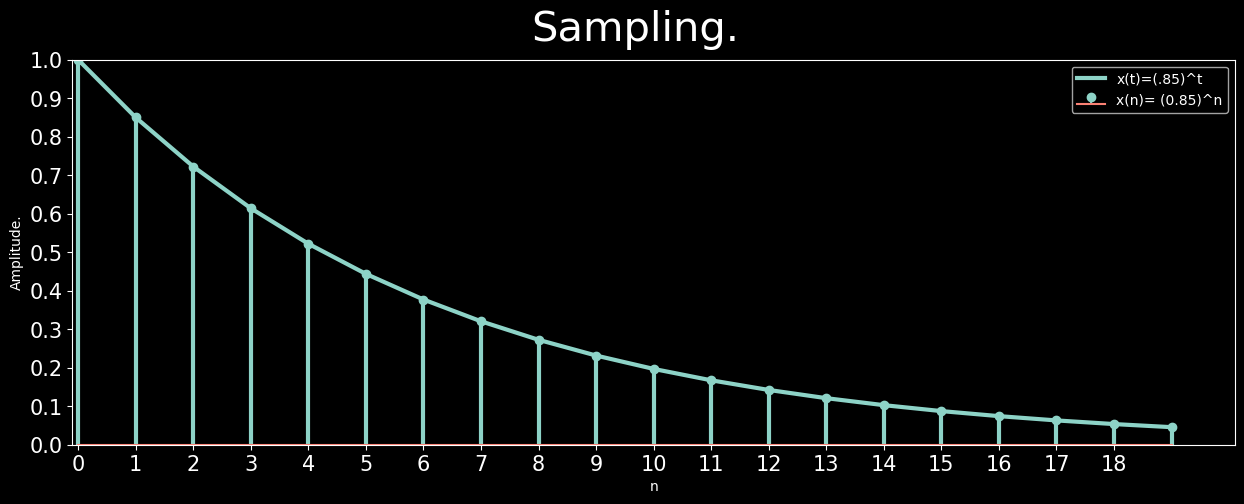

In [ ]:
#Sampling & Plotting the sampled signal.
plt.figure(figsize = (15,5))
plt.suptitle('Sampling.', fontsize=30)
style.use('dark_background')
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15


plt.plot(t,x, linewidth=3, label= 'x(t)=(.85)^t')
print(x.shape)
print(t.shape)
n = t
plt.axis([-0.1,20.1,0,1])
plt.xticks(xt)
plt.yticks(yt)

markerline, stemlines,  baseline = plt.stem(n,x, label='x(n)= (0.85)^n') # 
plt.setp(stemlines, 'linewidth', 3)
plt.xlabel('n')
plt.ylabel('Amplitude.')

plt.axis([-0.1,20.1,0,1])
plt.legend(fontsize=10)

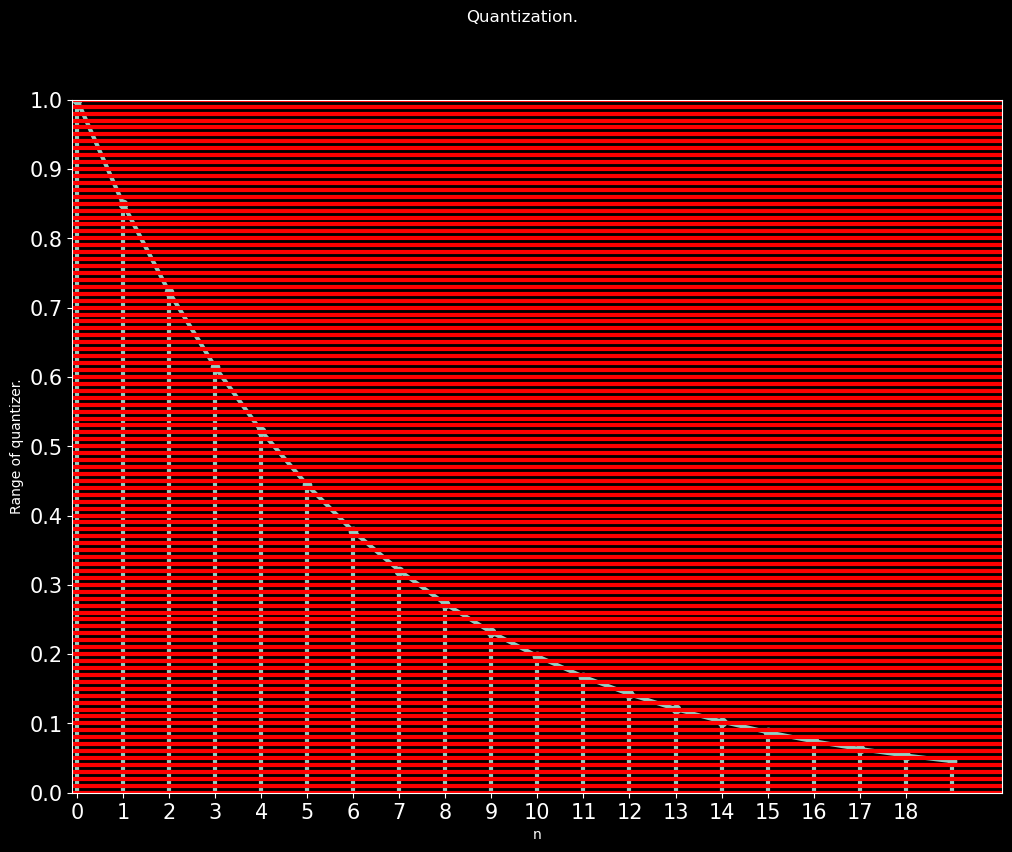

In [32]:
#Quantization
plt.figure(figsize = (12,9))
plt.suptitle('Quantization.')
style.use('dark_background')
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.plot(t,x, linewidth=3)
n = t
plt.axis([-0.1,20.1,0,1])
plt.xticks(xt)
plt.yticks(yt)

markerline, stemlines,  baseline = plt.stem(n,x)
plt.setp(stemlines, 'linewidth', 3)
plt.xlabel('n')
plt.ylabel('Range of quantizer.')
plt.axis([-0.1,20.1,0,1])

for y in np.arange(0., 2.1, 0.01):
    plt.axhline(y=y, xmin=0, xmax=10, color='r', linewidth=3.0)


plt.show()

In [ ]:
print(x)
xq = np.around(x,1) #Quantized signal a
print(xq)

[1.         0.85       0.7225     0.614125   0.52200625 0.44370531
 0.37714952 0.32057709 0.27249053 0.23161695 0.1968744  0.16734324
 0.14224176 0.12090549 0.10276967 0.08735422 0.07425109 0.06311342
 0.05364641 0.04559945]
[1.  0.8 0.7 0.6 0.5 0.4 0.4 0.3 0.3 0.2 0.2 0.2 0.1 0.1 0.1 0.1 0.1 0.1
 0.1 0. ]


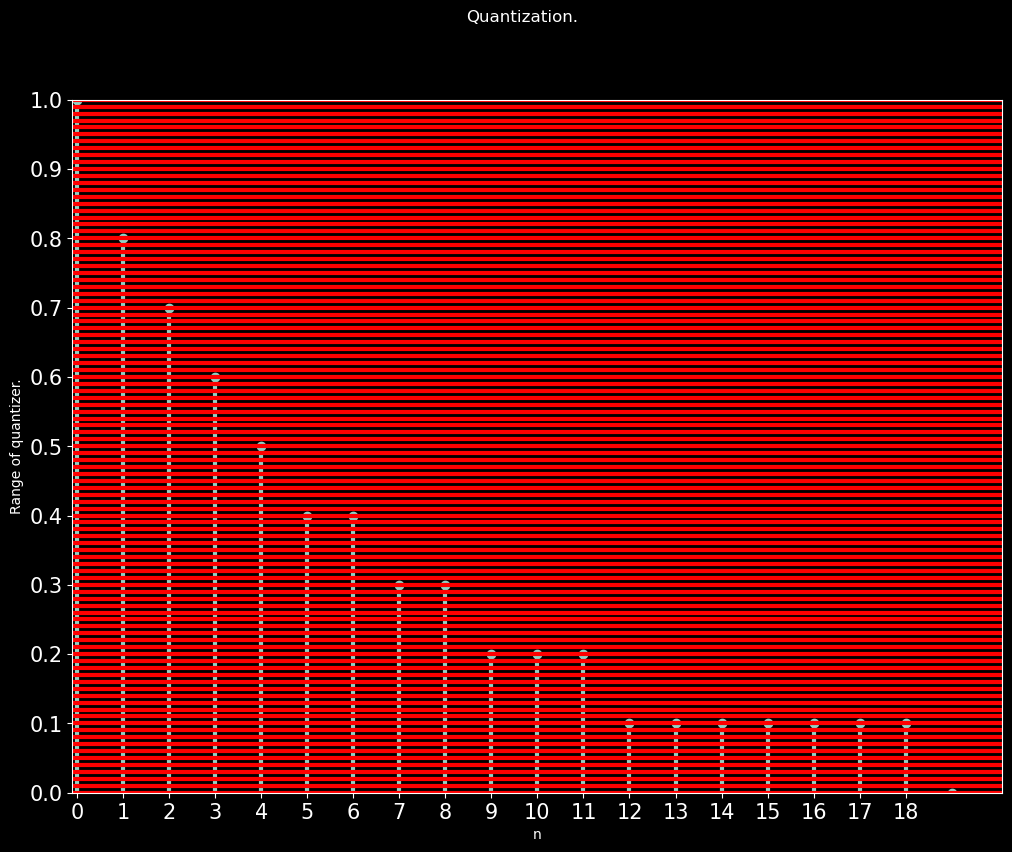

In [33]:
#Plotting quantized signal

#Quantization
plt.figure(figsize = (12,9))
plt.suptitle('Quantization.')
style.use('dark_background')
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15


plt.axis([-0.1,20.1,0,1])
plt.xticks(xt)
plt.yticks(yt)

markerline, stemlines,  baseline = plt.stem(n,xq) # xq is quantized signal
plt.setp(stemlines, 'linewidth', 3)
plt.xlabel('n')
plt.ylabel('Range of quantizer.')
plt.axis([-0.1,20.1,0,1])

for y in np.arange(0., 2.1, 0.01):
    plt.axhline(y=y, xmin=0, xmax=10, color='r', linewidth=3.0)


plt.show()

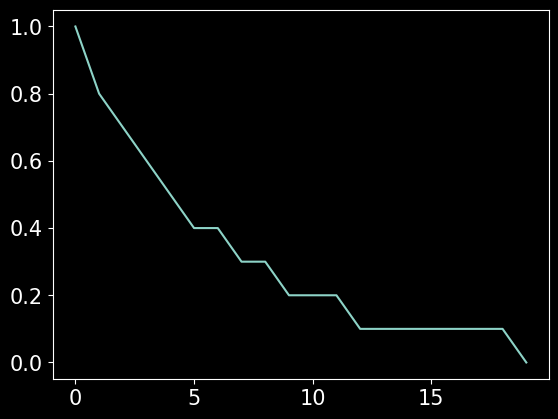

In [34]:
plt.plot(n,xq)
plt.show()

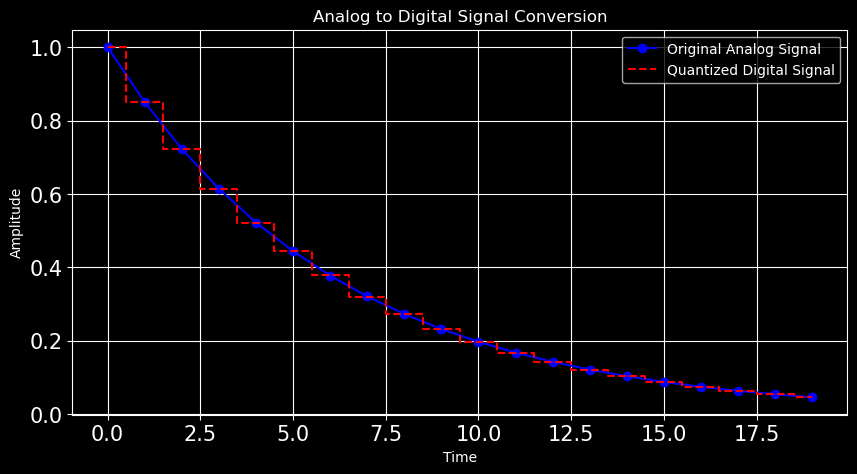

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Sampling (already done)
t = np.arange(0, 20, 1)
x = (0.85)**t

# Step 2: Normalize x between 0 and 1
x_min = np.min(x)
x_max = np.max(x)
x_norm = (x - x_min) / (x_max - x_min)

# Step 3: Quantize to 8-bit (256 levels)
levels = 256
x_quantized = np.round(x_norm * (levels - 1)) / (levels - 1)

# Step 4: Denormalize (optional - back to original amplitude range)
x_digital = x_quantized * (x_max - x_min) + x_min

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(t, x, 'b-o', label='Original Analog Signal')
plt.step(t, x_digital, 'r--', where='mid', label='Quantized Digital Signal')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Analog to Digital Signal Conversion')
plt.grid(True)
plt.show()


(10000,)


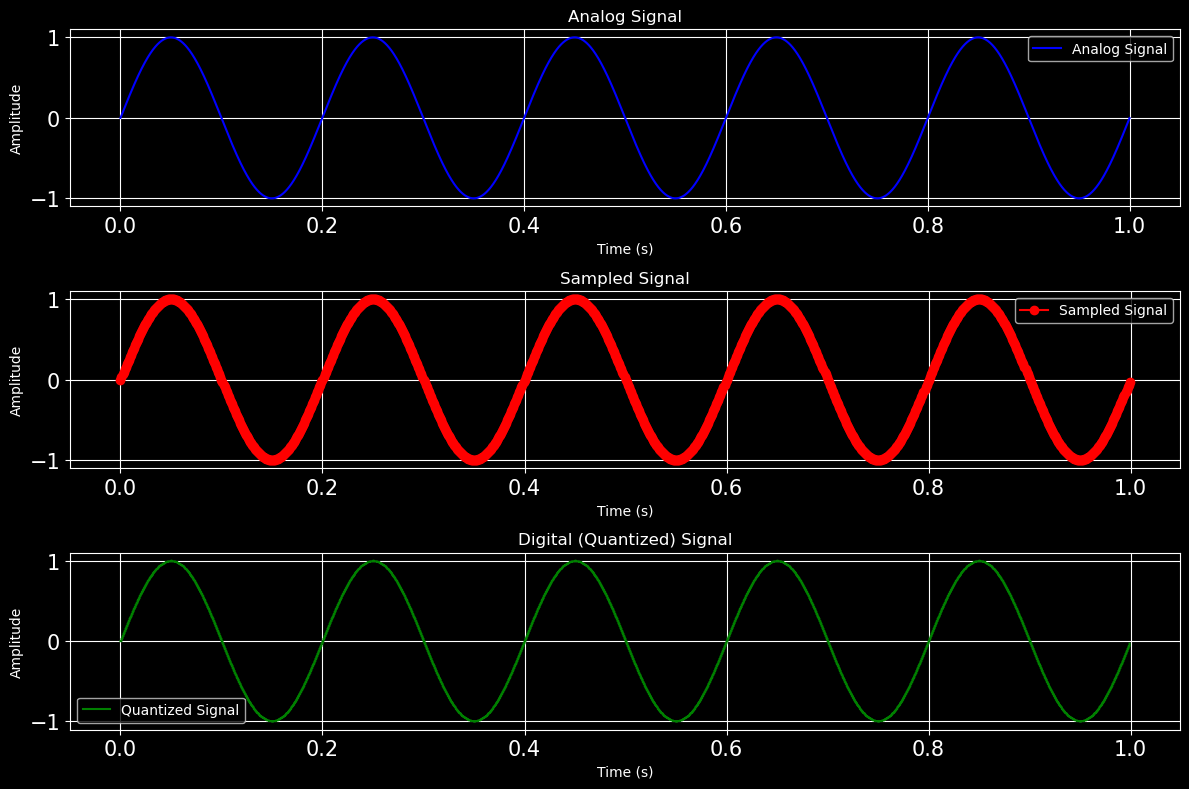

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
duration = 1.0  # Duration of the signal in seconds
fs = 1000  # Sampling frequency in Hz
f = 5  # Frequency of the sine wave in Hz
num_bits = 8  # Number of bits for quantization (e.g., 8-bit ADC)
amplitude = 1.0  # Amplitude of the analog signal

# Step 1: Generate the analog signal (sine wave)
t = np.linspace(0, duration, int(fs * duration * 10), endpoint=False)  # High-resolution time for analog signal
print(t.shape)
analog_signal = amplitude * np.sin(2 * np.pi * f * t)

# Step 2: Sample the analog signal
ts = np.arange(0, duration, 1/fs)  # Sampling time points
sampled_signal = amplitude * np.sin(2 * np.pi * f * ts)

# Step 3: Quantize the sampled signal
num_levels = 2**num_bits  # Number of quantization levels
max_voltage = amplitude
min_voltage = -amplitude
quantization_step = (max_voltage - min_voltage) / (num_levels - 1)

# Quantize by rounding to the nearest quantization level
quantized_signal = np.round(sampled_signal / quantization_step) * quantization_step
# Step 4: Plot the results
plt.figure(figsize=(12, 8))

# Plot original analog signal
plt.subplot(3, 1, 1)
plt.plot(t, analog_signal, 'b-', label='Analog Signal')
plt.title('Analog Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()

# Plot sampled signal
plt.subplot(3, 1, 2)
plt.plot(ts, sampled_signal, 'ro-', label='Sampled Signal')
plt.title('Sampled Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()

# Plot quantized (digital) signal
plt.subplot(3, 1, 3)
plt.step(ts, quantized_signal, 'g-', where='post', label='Quantized Signal')
plt.title('Digital (Quantized) Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig('adc_conversion.png')